# Pipeline for Barcode Detection and Decoding

This notebook documents the design and implementation of a two-stage pipeline for accurately detecting and decoding barcodes from images. The primary objective is to build a robust system capable of handling barcodes in real-world conditions, including variable lighting, perspective distortion, and image noise.

The final, recommended pipeline consists of:
1.  **Stage 1: Detection:** A fine-tuned **YOLOv8s** model identifies the location of barcodes within a source image, producing precise bounding boxes.

2.  **Stage 2: Normalization & Decoding:**
    - A series of robust computer vision functions are applied to each detected bounding box to perform **perspective correction**, isolating and un-warping the barcode into a flat, frontal view.
    - This document also details the initial exploration of a \"from-scratch\" decoding implementation.

I want to note right away that the pipeline isn't complete as I haven't been able to find an effective way to correctly decode the barcodes.
I managed to capture the barcodes correctly and, in most cases, perform the projection to make the barcode as straight as possible. However, I haven't been able to decode it correctly, as the most difficult step has been measuring the correct widths between the various bars.

**Sensitivity to Noise:** Minor image noise, artifacts from JPEG compression, or non-uniform lighting consistently corrupted the measured bar/space widths, leading to an incorrect number of detected elements.

**Symbology Complexity:** Barcode standards like Code 128 feature multiple character sets, mode-switching characters, and a complex checksum, making a full, robust implementation a significant engineering task in itself.

**Error Propagation:** Small errors in the initial module width calculation would cascade, rendering the entire normalized pattern unusable.

### The Pipeline Explained

- **Object Detection with Fine-Tuned YOLOv8s:** The YOLOv8s model is used to detect barcodes within images. This model was fine-tuned on a custom dataset of 5,000 images containing barcodes, allowing for fast and accurate detection.

- **Bounding Box Cleaning and Perspective Correction:** For each detected bounding box, a series of image preprocessing steps is applied, including Gaussian Blur, Thresholding, Dilation, Erosion, and Canny Edge Detection. These techniques help enhance image quality by removing noise and compensating for shadows or irregular shapes of the packages. The goal is to isolate and clean the barcode region as much as possible. Once the image has been cleaned, a perspective transformation is applied to straighten the barcode, making it easier to read and decode.

- **Barcode Decoding:** After obtaining a clean and properly aligned image of the barcode, the next step is decoding. This has proven to be the most challenging part of the pipeline. Despite experimenting with various computer vision techniques, I was unable to achieve consistently reliable decoding results. The main difficulty lies in the wide variety of barcode formats, each requiring different approaches for accurate interpretation. Additionally, image quality and lighting conditions significantly affect decoding performance.
Nonetheless, the code for the decoding process has been included to document the progress made and to showcase the techniques explored so far.

### What can Be Improved
The first step to improving the entire pipeline is to enhance the perspective correction, ensuring that all barcodes are aligned horizontally. Once this is achieved, various image processing operations can be applied to further improve image quality and remove minor imperfections.

By calculating and leveraging the average pixel values across the barcode region, we can achieve a more uniform representation of the bars, making them easier to read. This normalization helps reduce the impact of lighting inconsistencies or noise.

After this preprocessing stage, the barcode can be translated into numerical values and decoded. Finally, the decoded barcode is stored in a CSV file for downstream use.

### How to Use This Notebook
1.  **Install Dependencies:** Run the dependency installation cell (Block 1) to set up the required Python libraries.
2. **Reload the Kernel:** After installing dependencies, reload the notebook kernel to ensure all libraries are correctly imported.
3.  **Execute All Cells:** Run the notebook from top to bottom to process the images and view the detection and decoding results.

#### Block 1: Dependencies Installation
This cell installs the necessary Python libraries for the project, including ultralytics for running the model, opencv-python for the operations on the images.

In [ ]:
%pip install ultralytics opencv-python matplotlib numpy huggingface_hub

#### Block 2: Importing Libraries
This block imports all the required libraries for image processing, deep learning, and data manipulation.

In [42]:
import os
import shutil

import cv2
import numpy as np
from ultralytics import YOLO
import matplotlib.pyplot as plt
from huggingface_hub import hf_hub_download

#### Block 3: Barcode Symbology Definitions
This block defines the patterns and lookup tables for EAN-13 and Code 128 barcode symbologies, which are essential for the decoding process.

In [43]:
# EAN-13 barcode patterns
L_CODES = {
    (3, 2, 1, 1): "0", (2, 2, 2, 1): "1", (2, 1, 2, 2): "2", (1, 4, 1, 1): "3",
    (1, 1, 3, 2): "4", (1, 2, 3, 1): "5", (1, 1, 1, 4): "6", (1, 3, 1, 2): "7",
    (1, 2, 1, 3): "8", (3, 1, 1, 2): "9"
}

G_CODES = {
    (1, 1, 2, 3): "0", (1, 2, 2, 2): "1", (2, 2, 1, 2): "2", (1, 1, 4, 1): "3",
    (2, 3, 1, 1): "4", (1, 3, 2, 1): "5", (4, 1, 1, 1): "6", (2, 1, 3, 1): "7",
    (3, 1, 2, 1): "8", (2, 1, 1, 3): "9"
}

# R_CODES are identical to L_CODES, but their binary representation is the reverse.
# for our width-based logic, the lookup table is the same.
R_CODES = L_CODES

# parity (sequence of L and G) determines the first digit.
PARITY_PATTERNS = {
    "LLLLLL": "0", "LLGLGG": "1", "LLGGLG": "2", "LLGGGL": "3", "LGLLGG": "4",
    "LGGLLG": "5", "LGGGLL": "6", "LGLGLG": "7", "LGLGGL": "8", "LGGLGL": "9"
}

# code 128 barcode patterns
CODE128_MAP = {
    (2, 1, 2, 2, 2, 2): (0, ' ', ' '), (2, 2, 2, 1, 2, 2): (1, '!', '!'), (2, 2, 2, 2, 2, 1): (2, '"', '"'),
    (1, 2, 1, 2, 2, 3): (3, '#', '#'), (1, 2, 1, 3, 2, 2): (4, '$', '$'), (1, 3, 1, 2, 2, 2): (5, '%', '%'),
    (1, 2, 2, 2, 1, 3): (6, '&', '&'), (1, 2, 2, 3, 1, 2): (7, "'", "'"), (1, 3, 2, 2, 1, 2): (8, '(', '('),
    (2, 2, 1, 2, 1, 3): (9, ')', ')'), (2, 2, 1, 3, 1, 2): (10, '*', '*'), (2, 3, 1, 2, 1, 2): (11, '+', '+'),
    (1, 1, 2, 2, 3, 2): (12, ',', ','), (1, 2, 2, 1, 3, 2): (13, '-', '-'), (1, 2, 2, 2, 3, 1): (14, '.', '.'),
    (1, 1, 3, 2, 2, 2): (15, '/', '/'), (1, 2, 3, 1, 2, 2): (16, '0', '0'), (1, 2, 3, 2, 2, 1): (17, '1', '1'),
    (2, 2, 3, 2, 1, 1): (18, '2', '2'), (2, 2, 1, 1, 3, 2): (19, '3', '3'), (2, 2, 1, 2, 3, 1): (20, '4', '4'),
    (2, 1, 3, 2, 1, 2): (21, '5', '5'), (2, 2, 3, 1, 1, 2): (22, '6', '6'), (3, 1, 2, 1, 3, 1): (23, '7', '7'),
    (3, 1, 1, 2, 2, 2): (24, '8', '8'), (3, 2, 1, 1, 2, 2): (25, '9', '9'), (3, 2, 1, 2, 2, 1): (26, ':', ':'),
    (3, 1, 2, 2, 1, 2): (27, ';', ';'), (3, 2, 2, 1, 1, 2): (28, '<', '<'), (3, 2, 2, 2, 1, 1): (29, '=', '='),
    (2, 1, 2, 1, 2, 3): (30, '>', '>'), (2, 1, 2, 3, 2, 1): (31, '?', '?'), (2, 3, 2, 1, 2, 1): (32, '@', '@'),
    (1, 1, 1, 3, 2, 3): (33, 'A', 'A'), (1, 3, 1, 1, 2, 3): (34, 'B', 'B'), (1, 3, 1, 3, 2, 1): (35, 'C', 'C'),
    (1, 1, 2, 3, 1, 3): (36, 'D', 'D'), (1, 3, 2, 1, 1, 3): (37, 'E', 'E'), (1, 3, 2, 3, 1, 1): (38, 'F', 'F'),
    (2, 1, 1, 3, 1, 3): (39, 'G', 'G'), (2, 3, 1, 1, 1, 3): (40, 'H', 'H'), (2, 3, 1, 3, 1, 1): (41, 'I', 'I'),
    (1, 1, 2, 1, 3, 3): (42, 'J', 'J'), (1, 1, 2, 3, 3, 1): (43, 'K', 'K'), (1, 3, 2, 1, 3, 1): (44, 'L', 'L'),
    (1, 1, 3, 1, 2, 3): (45, 'M', 'M'), (1, 1, 3, 3, 2, 1): (46, 'N', 'N'), (1, 3, 3, 1, 2, 1): (47, 'O', 'O'),
    (3, 1, 3, 1, 2, 1): (48, 'P', 'P'), (2, 1, 1, 3, 3, 1): (49, 'Q', 'Q'), (2, 3, 1, 1, 3, 1): (50, 'R', 'R'),
    (2, 1, 3, 1, 1, 3): (51, 'S', 'S'), (2, 1, 3, 3, 1, 1): (52, 'T', 'T'), (2, 1, 3, 1, 3, 1): (53, 'U', 'U'),
    (3, 1, 1, 1, 2, 3): (54, 'V', 'V'), (3, 1, 1, 3, 2, 1): (55, 'W', 'W'), (3, 3, 1, 1, 2, 1): (56, 'X', 'X'),
    (3, 1, 2, 1, 1, 3): (57, 'Y', 'Y'), (3, 1, 2, 3, 1, 1): (58, 'Z', 'Z'), (3, 3, 2, 1, 1, 1): (59, '[', '['),
    (3, 1, 4, 1, 1, 1): (60, '\\', '\\'), (2, 2, 1, 4, 1, 1): (61, ']', ']'), (4, 3, 1, 1, 1, 1): (62, '^', '^'),
    (1, 1, 1, 2, 2, 4): (63, '_', '_'), (1, 1, 1, 4, 2, 2): (64, '`', 'NUL'), (1, 2, 1, 1, 2, 4): (65, 'a', 'SOH'),
    (1, 2, 1, 4, 2, 1): (66, 'b', 'STX'), (1, 4, 1, 1, 2, 2): (67, 'c', 'ETX'), (1, 4, 1, 2, 2, 1): (68, 'd', 'EOT'),
    (1, 1, 2, 2, 1, 4): (69, 'e', 'ENQ'), (1, 1, 2, 4, 1, 2): (70, 'f', 'ACK'), (1, 2, 2, 1, 1, 4): (71, 'g', 'BEL'),
    (1, 2, 2, 4, 1, 1): (72, 'h', 'BS'), (1, 4, 2, 1, 1, 2): (73, 'i', 'HT'), (1, 4, 2, 2, 1, 1): (74, 'j', 'LF'),
    (2, 4, 1, 2, 1, 1): (75, 'k', 'VT'), (2, 2, 1, 1, 1, 4): (76, 'l', 'FF'), (4, 1, 3, 1, 1, 1): (77, 'm', 'CR'),
    (2, 4, 1, 1, 1, 2): (78, 'n', 'SO'), (1, 3, 4, 1, 1, 1): (79, 'o', 'SI'), (1, 1, 1, 2, 4, 2): (80, 'p', 'DLE'),
    (1, 2, 1, 1, 4, 1): (81, 'q', 'DC1'), (1, 2, 1, 2, 4, 1): (82, 'r', 'DC2'), (1, 1, 4, 2, 1, 2): (83, 's', 'DC3'),
    (1, 2, 4, 1, 1, 2): (84, 't', 'DC4'), (1, 2, 4, 2, 1, 1): (85, 'u', 'NAK'), (4, 1, 1, 2, 1, 2): (86, 'v', 'SYN'),
    (4, 2, 1, 1, 1, 2): (87, 'w', 'ETB'), (4, 2, 1, 2, 1, 1): (88, 'x', 'CAN'), (2, 1, 2, 1, 4, 1): (89, 'y', 'EM'),
    (2, 1, 4, 1, 2, 1): (90, 'z', 'SUB'), (4, 1, 2, 1, 2, 1): (91, '{', 'ESC'), (1, 1, 1, 1, 4, 3): (92, '|', 'FS'),
    (1, 1, 1, 3, 4, 1): (93, '}', 'GS'), (1, 3, 1, 1, 4, 1): (94, '~', 'RS'), (1, 1, 4, 1, 1, 3): (95, 'DEL', 'US'),
    (1, 1, 4, 3, 1, 1): (96, None, None), # FNC3
    (4, 1, 1, 1, 1, 3): (97, None, None), # FNC2
    (4, 1, 1, 3, 1, 1): (98, None, None), # SHIFT
    (1, 1, 3, 1, 4, 1): (99, None, None), # Code C
    (1, 1, 4, 1, 3, 1): (100, None, None),# Code B (FNC4)
    (3, 1, 1, 1, 4, 1): (101, None, None),# Code A (FNC4)
    (4, 1, 1, 1, 3, 1): (102, None, None),# FNC1
    (2, 1, 1, 4, 1, 2): (103, None, None),# Start A
    (2, 1, 1, 2, 1, 4): (104, None, None),# Start B
    (2, 1, 1, 2, 3, 2): (105, None, None),# Start C
    (2, 3, 3, 1, 1, 1, 2): (106, None, None) # Stop (special pattern of 7 bars)
}

VALUE_TO_CHAR_B = {v[0]: v[1] for k, v in CODE128_MAP.items() if v[0] <= 102}
START_B_PATTERN = (2, 1, 1, 2, 1, 4)
STOP_PATTERN = (2, 3, 3, 1, 1, 1, 2)


#### Block 4: Configuration Constants and Model Initialization
This cell defines high-level configuration constants for the pipeline, such as the path to the YOLO model, the input image directory, and the confidence threshold for object detection. It then loads the YOLO model.

In [ ]:
target_dir = "input_images"
os.makedirs(target_dir, exist_ok=True)

!wget -P input_images https://raw.githubusercontent.com/Piero24/Detect-Decode-the-Barcode/bec2a8945380854a9314e36fc9d63ceee942f386/input_images/m_1.jpg
!wget -P input_images https://raw.githubusercontent.com/Piero24/Detect-Decode-the-Barcode/bec2a8945380854a9314e36fc9d63ceee942f386/input_images/m_2.jpg
!wget -P input_images https://raw.githubusercontent.com/Piero24/Detect-Decode-the-Barcode/bec2a8945380854a9314e36fc9d63ceee942f386/input_images/m_3.jpg
!wget -P input_images https://raw.githubusercontent.com/Piero24/Detect-Decode-the-Barcode/bec2a8945380854a9314e36fc9d63ceee942f386/input_images/m_4.jpg
!wget -P input_images https://raw.githubusercontent.com/Piero24/Detect-Decode-the-Barcode/bec2a8945380854a9314e36fc9d63ceee942f386/input_images/m_5.jpg
!wget -P input_images https://raw.githubusercontent.com/Piero24/Detect-Decode-the-Barcode/bec2a8945380854a9314e36fc9d63ceee942f386/input_images/m_6.jpg

In [45]:
_MODEL_REPO = "Piero2411/YOLOV8s-Barcode-Detection"
_MODEL_FILENAME = "YOLOV8s_Barcode_Detection.pt"

print(f"Loading model '{_MODEL_FILENAME}' from Hugging Face Hub...")

# download to cache
cached_model_path = hf_hub_download(
    repo_id=_MODEL_REPO,
    filename=_MODEL_FILENAME
)

# optionally move it to current directory
shutil.copy(cached_model_path, f"./{_MODEL_FILENAME}")

_INPUT_IMAGE_DIRECTORY = 'input_images'
_CONFIDENCE_THRESHOLD = 0.2

_YOLO_MODEL = YOLO(_MODEL_FILENAME)
_CLASS_NAMES = _YOLO_MODEL.names

Loading model 'YOLOV8s_Barcode_Detection.pt' from Hugging Face Hub...


#### Block 5: Input Image Verification
This cell verifies the existence of the input image directory and checks for image files within it, providing error messages if issues are found.

In [46]:
try:
    _IMAGE_FILES = [
        f for f in os.listdir(_INPUT_IMAGE_DIRECTORY)
        if f.lower().endswith(('.png', '.jpg', '.jpeg'))
    ]
    if not _IMAGE_FILES:
        print(
            f"ERROR: No images found in the "
            f"'{_INPUT_IMAGE_DIRECTORY}' directory."
        )

except FileNotFoundError:
    print(
        f"ERROR: The input directory "
        f"'{_INPUT_IMAGE_DIRECTORY}' was not found."
    )

#### Block 6: Image Normalization Utilities
This block contains utility functions for image normalization, which are crucial for correcting perspective distortions and isolating the barcode region.

In [47]:
def _apply_first_pass_normalization(image: np.ndarray) -> np.ndarray | None:
    """Performs the first pass of image normalization to isolate the main
        region of interest. This function applies a series of image processing
        steps including grayscale conversion, blurring, edge detection,
        thresholding, and morphological operations to identify and mask the
        largest contour in the image. This is typically used to segment the
        primary object or area from the background.

    Args:
        image (np.ndarray): The input image as a NumPy array (BGR format).

    Returns:
        A new NumPy array representing the masked image with the region of
        interest, or None if no contours are found.
    """
    image_copy = image.copy()

    gray_image = cv2.cvtColor(image_copy, cv2.COLOR_BGR2GRAY)
    blurred_gray = cv2.GaussianBlur(gray_image, (9, 9), 0)
    edged_image = cv2.Canny(blurred_gray, 100, 250)
    blurred_edged = cv2.GaussianBlur(edged_image, (13, 13), 0)

    _, threshold = cv2.threshold(
        blurred_edged,
        0, 255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    blurred = cv2.GaussianBlur(threshold, (13, 13), 0)

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (28, 7))
    closed = cv2.morphologyEx(blurred, cv2.MORPH_CLOSE, kernel)
    dilated = cv2.dilate(closed, None, iterations=15)

    contours, _ = cv2.findContours(
        dilated.copy(),
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if not contours:
        return None

    largest_contour = max(contours, key=cv2.contourArea)
    mask = np.zeros(gray_image.shape, dtype=np.uint8)
    cv2.drawContours(mask, [largest_contour], -1, 255, cv2.FILLED)

    masked_output_image = cv2.bitwise_and(image_copy, image_copy, mask=mask)
    return masked_output_image


def _apply_second_pass_normalization(masked_image: np.ndarray) -> tuple | None:
    """Performs the second pass of image normalization to refine the region of
        interest. This function takes an already masked image and applies
        further image processing steps to precisely identify the main contour
        and calculate its minimum area bounding box.

    Args:
        masked_image (np.ndarray): The input masked image as a NumPy array (
            BGR format).

    Returns:
        A tuple representing the minimum area bounding box ((center_x, center_y),
        (width, height), angle of rotation), or None if no contours are found.
    """
    image_copy = masked_image.copy()

    gray_image = cv2.cvtColor(image_copy, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray_image, (9, 9), 0)
    _, threshold = cv2.threshold(
        blurred,
        0, 250,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    eroded = cv2.erode(threshold, None, iterations=2)
    blurred = cv2.GaussianBlur(eroded, (11, 11), 0)
    _, threshold = cv2.threshold(
        blurred,
        0, 250,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (28, 7))
    closed = cv2.morphologyEx(threshold, cv2.MORPH_CLOSE, kernel)
    eroded = cv2.erode(closed, None, iterations=4)
    return eroded


def normalize_barcode_perspective(image: np.ndarray) -> np.ndarray:
    """Normalizes a barcode image by isolating the barcode region and applying
        a perspective transform. This function leverages a two-pass
        normalization approach to first identify a broader region of interest
        and then refine it to pinpoint the barcode. It then calculates
        the perspective transformation to unwarp and straighten the barcode,
        returning a normalized, upright image.

    Args:
        image (np.ndarray): The input image containing the barcode as a NumPy
            array (BGR format).

    Returns:
        A new NumPy array representing the normalized and unwarped barcode image.
        If barcode detection fails at any stage, the original image is returned.
    """
    # first pass: Isolate the main region of interest.
    first_pass_image = _apply_first_pass_normalization(image)
    if first_pass_image is None:
        print(
            "Warning: No prominent contours found in the first normalization "
            "pass. Returning original image."
        )
        return image

    # second pass: Refine the region and get the bounding box.
    second_pass_image = _apply_second_pass_normalization(first_pass_image)
    if second_pass_image is None:
        print(
            "Warning: No refined contours found in the second normalization "
            "pass. Returning original image."
        )
        return image

    contours, _ = cv2.findContours(
        second_pass_image.copy(),
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if not contours:
        return None

    largest_contour = max(contours, key=cv2.contourArea)
    rotated_bounding_box = cv2.minAreaRect(largest_contour)

    # get the 4 vertices of the rotated rectangle.
    box_points = cv2.boxPoints(rotated_bounding_box)
    points = np.intp(box_points)

    # order the corners of the rectangle consistently (top-left, top-right,
    # bottom-right, bottom-left).
    ordered_rect_coordinates = np.zeros((4, 2), dtype="float32")

    sum_coords = points.sum(axis=1)
    ordered_rect_coordinates[0] = points[np.argmin(sum_coords)]  # Top-left
    ordered_rect_coordinates[2] = points[np.argmax(sum_coords)]  # Bottom-right

    diff_coords = np.diff(points, axis=1)
    ordered_rect_coordinates[1] = points[np.argmin(diff_coords)] # Top-right
    ordered_rect_coordinates[3] = points[np.argmax(diff_coords)] # Bottom-left

    (top_left, top_right, bottom_right, bottom_left) = ordered_rect_coordinates

    # apply the perspective transformation to unwarp the barcode.
    # calculate the width of the new image based on the distances between
    # horizontal points.
    width_top = np.sqrt(
        ((bottom_right[0] - bottom_left[0]) ** 2) +
        ((bottom_right[1] - bottom_left[1]) ** 2)
    )
    width_bottom = np.sqrt(
        ((top_right[0] - top_left[0]) ** 2) +
        ((top_right[1] - top_left[1]) ** 2)
    )
    max_width = max(int(width_top), int(width_bottom))

    # calculate the height of the new image based on the distances between
    # vertical points.
    height_right = np.sqrt(
        ((top_right[0] - bottom_right[0]) ** 2) +
        ((top_right[1] - bottom_right[1]) ** 2)
    )
    height_left = np.sqrt(
        ((top_left[0] - bottom_left[0]) ** 2) +
        ((top_left[1] - bottom_left[1]) ** 2)
    )
    max_height = max(int(height_right), int(height_left))

    # define the destination points for the "bird's-eye view" perspective.
    destination_points = np.array([
        [0, 0],                            # Top-Left
        [max_width - 1, 0],                # Top-Right
        [max_width - 1, max_height - 1],   # Bottom-Right
        [0, max_height - 1]],              # Bottom-Left
        dtype=np.float32)

    # compute the perspective transform matrix and apply it.
    perspective_matrix = cv2.getPerspectiveTransform(
        ordered_rect_coordinates, destination_points
    )
    warped_image = cv2.warpPerspective(
        image, perspective_matrix, (max_width, max_height)
    )

    # check the orientation of the resulting image. If height is greater than
    # width, rotate it 90 degrees clockwise.
    height_warped, width_warped, _ = warped_image.shape
    if height_warped > width_warped:
        warped_image = cv2.rotate(warped_image, cv2.ROTATE_90_CLOCKWISE)

    return warped_image


def enhance_barcode_image(image: np.ndarray) -> np.ndarray | None:
    """Enhances the barcode region within a normalized image for better decoding.
        This function applies gradient analysis, thresholding, and morphological
        operations to refine the barcode region and extract a clean, masked image.

    Args:
        image: The input image (full image from which ROI was taken).

    Returns:
        A cropped and masked image containing the enhanced barcode, or None
            if processing fails.
    """
    if image is None or image.size == 0:
        print("Input 'image' is not defined or is empty.")
        return None

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    grad_x = cv2.Sobel(gray, ddepth=cv2.CV_32F, dx=1, dy=0, ksize=-1)  # Scharr 3x3

    blurred_grad = cv2.GaussianBlur(grad_x, (1, 5), 0)
    blurred_grad = cv2.convertScaleAbs(blurred_grad)

    _, grad_thresh = cv2.threshold(blurred_grad, 225, 255, cv2.THRESH_BINARY)

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (21, 7))
    closed_grad = cv2.morphologyEx(grad_thresh, cv2.MORPH_CLOSE, kernel)

    closed_grad = cv2.erode(closed_grad, None, iterations=4)
    closed_grad = cv2.dilate(closed_grad, None, iterations=4)

    contours, _ = cv2.findContours(
        closed_grad,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if not contours:
        return None

    c = max(contours, key=cv2.contourArea)

    original_mask = np.zeros(image.shape[:2], dtype=np.uint8)
    cv2.drawContours(original_mask, [c], -1, 255, -1)
    original_mask = cv2.dilate(original_mask, None, iterations=4)

    barcode = cv2.bitwise_and(image, image, mask=original_mask)
    return barcode

#### Block 7: Main Processing Loop
This cell orchestrates the main pipeline: it iterates through input images, performs barcode detection using YOLOv8s, applies image normalization and enhancement to detected barcodes, and stores the processed images for further decoding.

In [48]:
detected_barcode_images = []

for filename in _IMAGE_FILES:
    print(f"\n--- Processing: {filename} ---")
    image_path = os.path.join(_INPUT_IMAGE_DIRECTORY, filename)
    img = cv2.imread(image_path)
    if img is None:
        print("Could not read image, skipping.")
        continue

    results = _YOLO_MODEL.predict(source=img, conf=_CONFIDENCE_THRESHOLD)
    result = results[0]

    if len(result.boxes) == 0:
        print("No objects detected.")
        continue

    print(f"Detected {len(result.boxes)} objects. Normalizing and plotting:")

    current_image_barcodes = []
    for box in result.boxes:
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
        class_id = int(box.cls[0])
        confidence = float(box.conf[0])
        label = f"{_CLASS_NAMES[class_id]}: {confidence:.2f}"

        # original crop
        cropped_img = img[y1:y2, x1:x2]

        if cropped_img.size == 0:
            print(f"Warning: Skipped an empty crop for {label}")
            continue

        normalized_img = normalize_barcode_perspective(cropped_img)
        polished_image = enhance_barcode_image(normalized_img)

        current_image_barcodes.append(
            {
                "original_image": img,
                "cropped_barcode_roi": cropped_img,
                "normalized_barcode_image": normalized_img,
                "polished_barcode_image": polished_image,
                "label": label
            }
        )

    detected_barcode_images.append(current_image_barcodes)


--- Processing: m_3.jpg ---

0: 640x480 2 barcodes, 12.9ms
Speed: 4.3ms preprocess, 12.9ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 480)
Detected 2 objects. Normalizing and plotting:

--- Processing: m_4.jpg ---

0: 640x480 3 barcodes, 16.8ms
Speed: 4.1ms preprocess, 16.8ms inference, 2.4ms postprocess per image at shape (1, 3, 640, 480)
Detected 3 objects. Normalizing and plotting:

--- Processing: m_2.jpg ---

0: 640x480 2 barcodes, 12.2ms
Speed: 4.4ms preprocess, 12.2ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 480)
Detected 2 objects. Normalizing and plotting:

--- Processing: m_5.jpg ---

0: 640x480 2 barcodes, 20.6ms
Speed: 6.5ms preprocess, 20.6ms inference, 2.6ms postprocess per image at shape (1, 3, 640, 480)
Detected 2 objects. Normalizing and plotting:

--- Processing: m_6.jpg ---

0: 640x576 2 barcodes, 96.4ms
Speed: 3.8ms preprocess, 96.4ms inference, 7.4ms postprocess per image at shape (1, 3, 640, 576)
Detected 2 objects. Normalizing

#### Block 8: Display the polished images (DEBUGGING)
This function displays the processed images with bounding boxes and normalized barcodes, allowing for visual verification of the detection and normalization steps.


--- Detected Barcodes in Image 1 ---
Barcode 1: barcode: 0.86


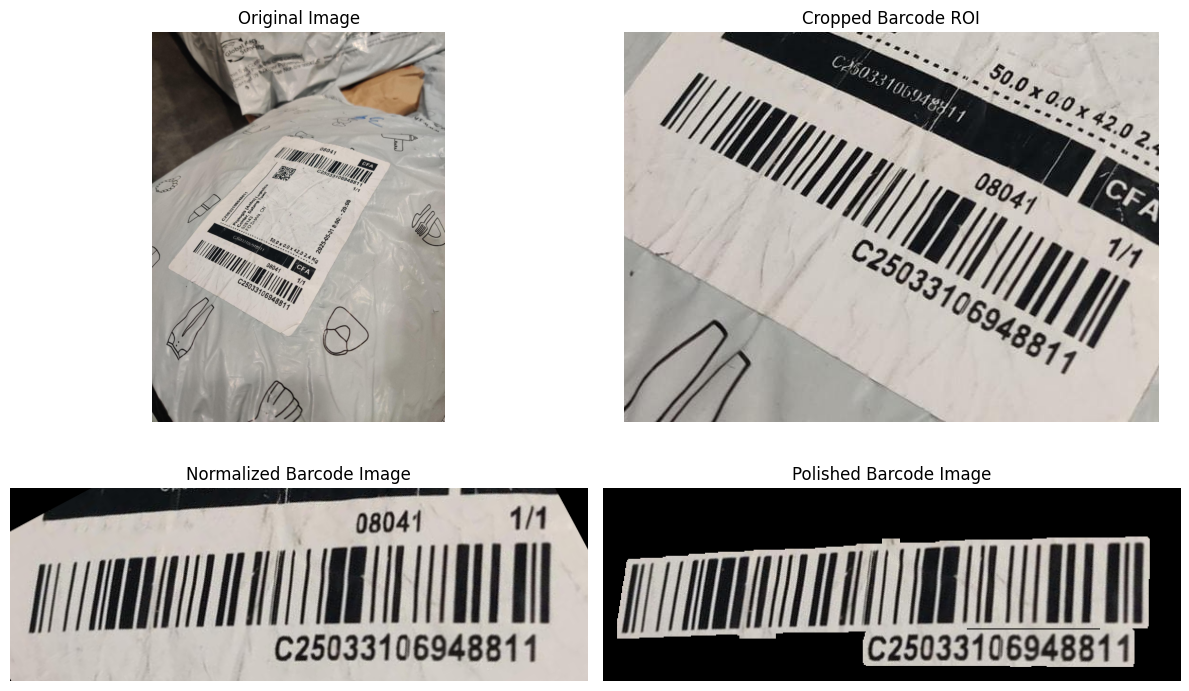

Barcode 2: barcode: 0.41


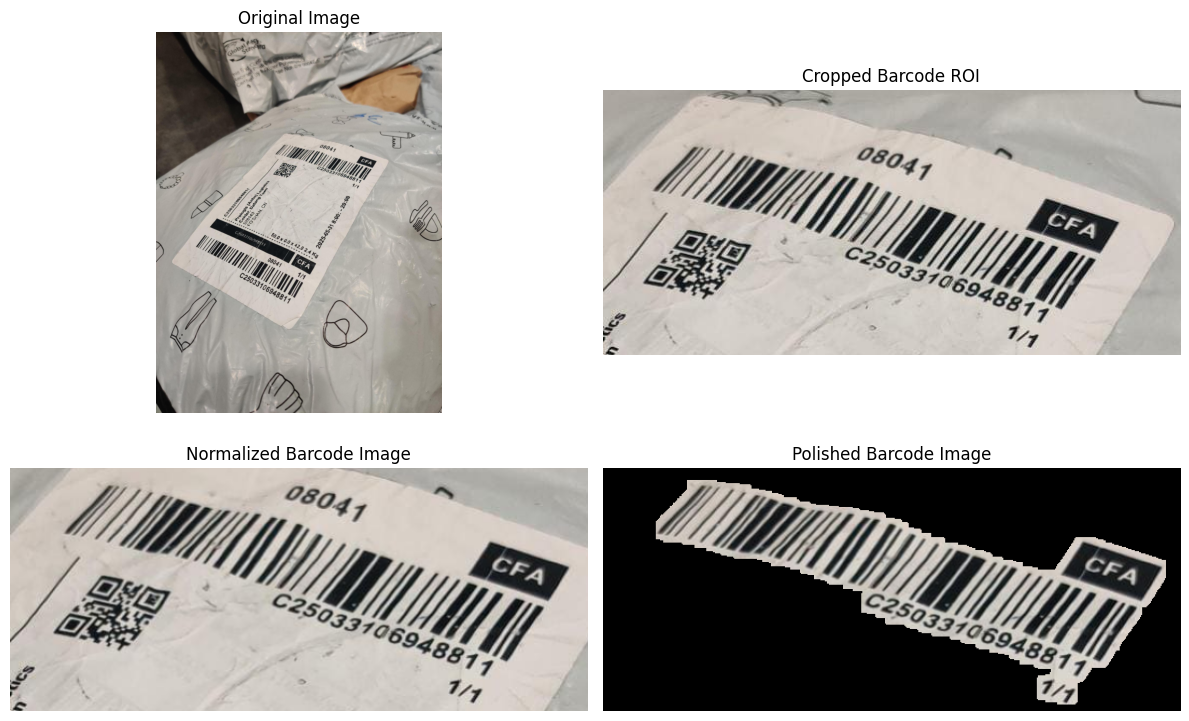


--- Detected Barcodes in Image 2 ---
Barcode 1: barcode: 0.78


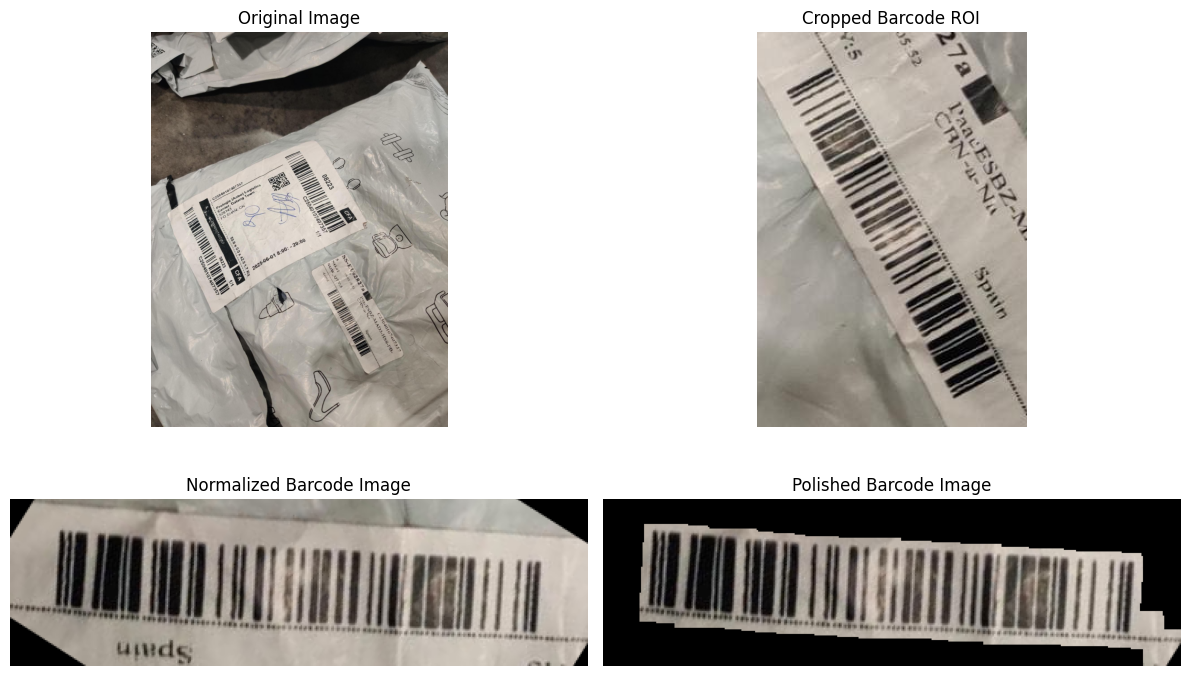

Barcode 2: barcode: 0.68


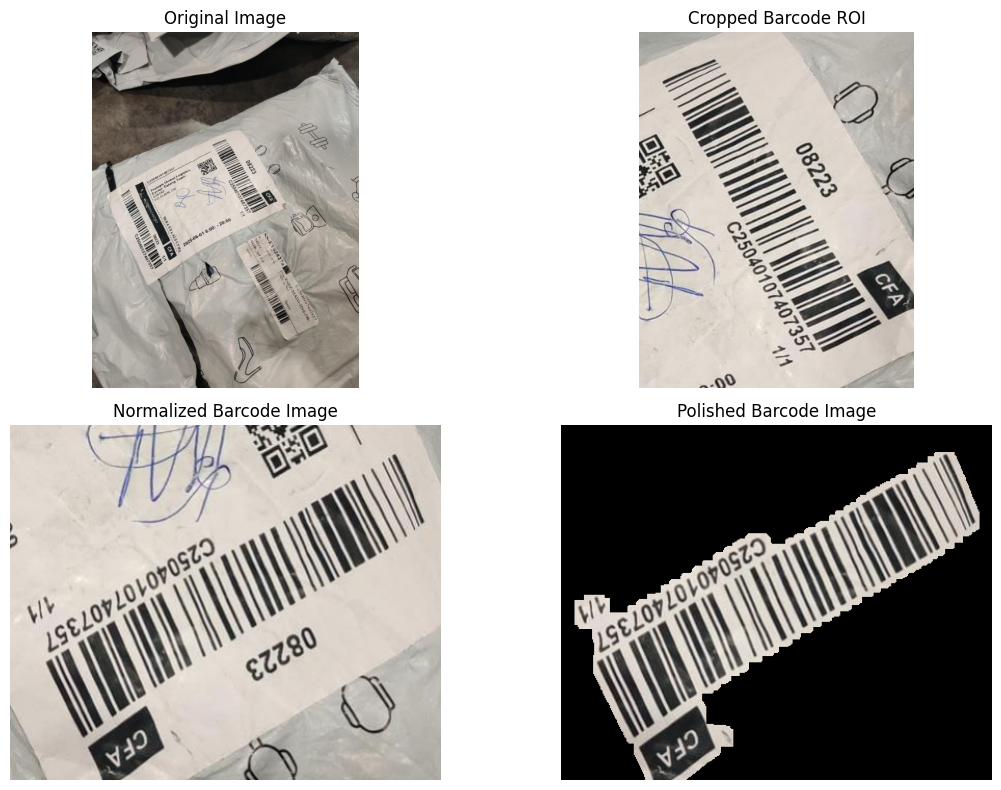

Barcode 3: barcode: 0.64


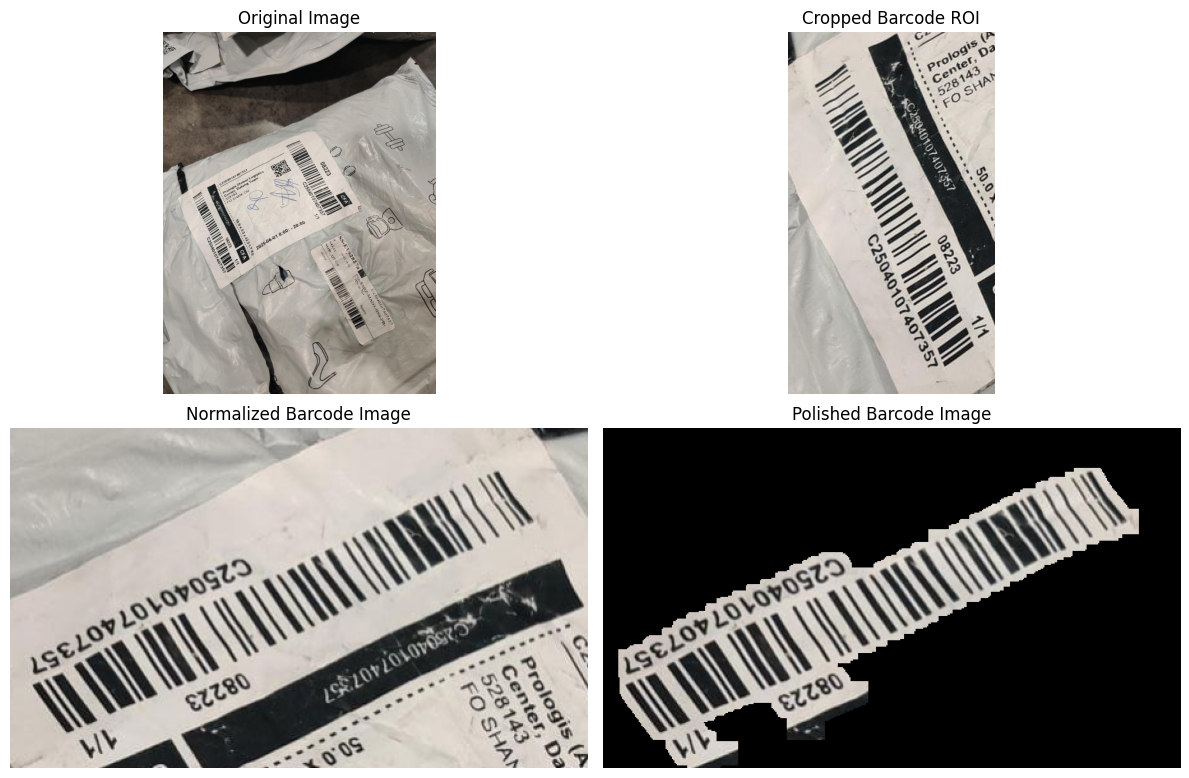


--- Detected Barcodes in Image 3 ---
Barcode 1: barcode: 0.84


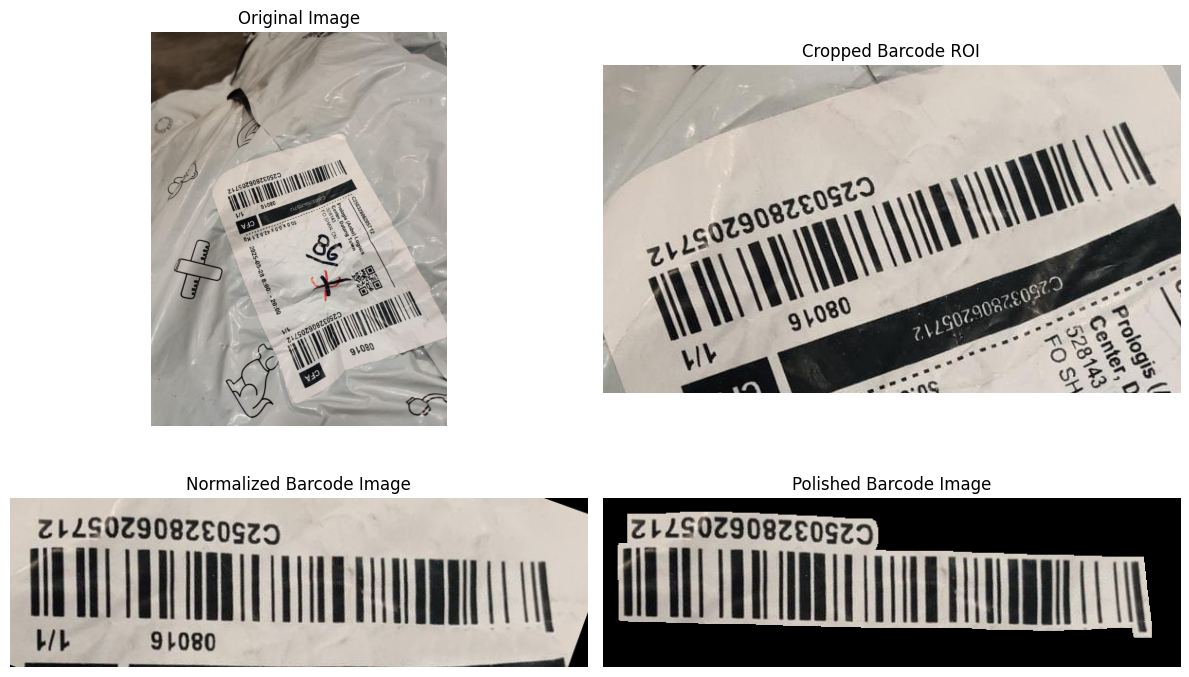

Barcode 2: barcode: 0.82


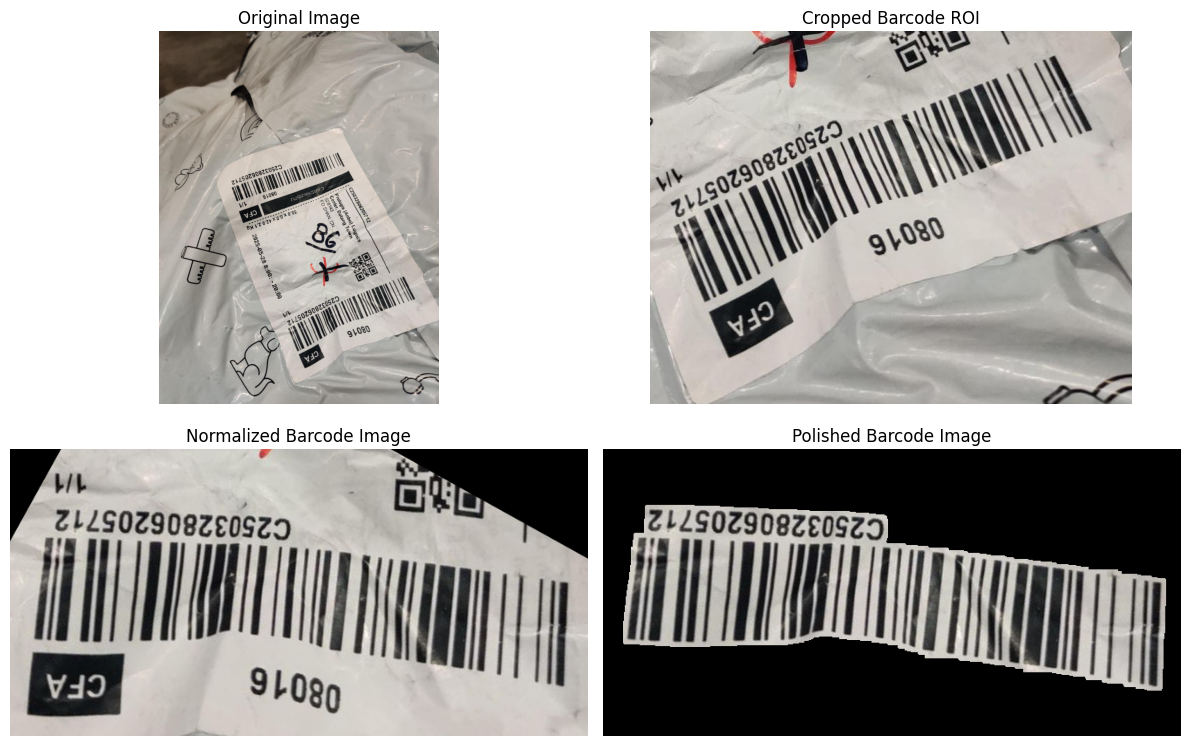


--- Detected Barcodes in Image 4 ---
Barcode 1: barcode: 0.70


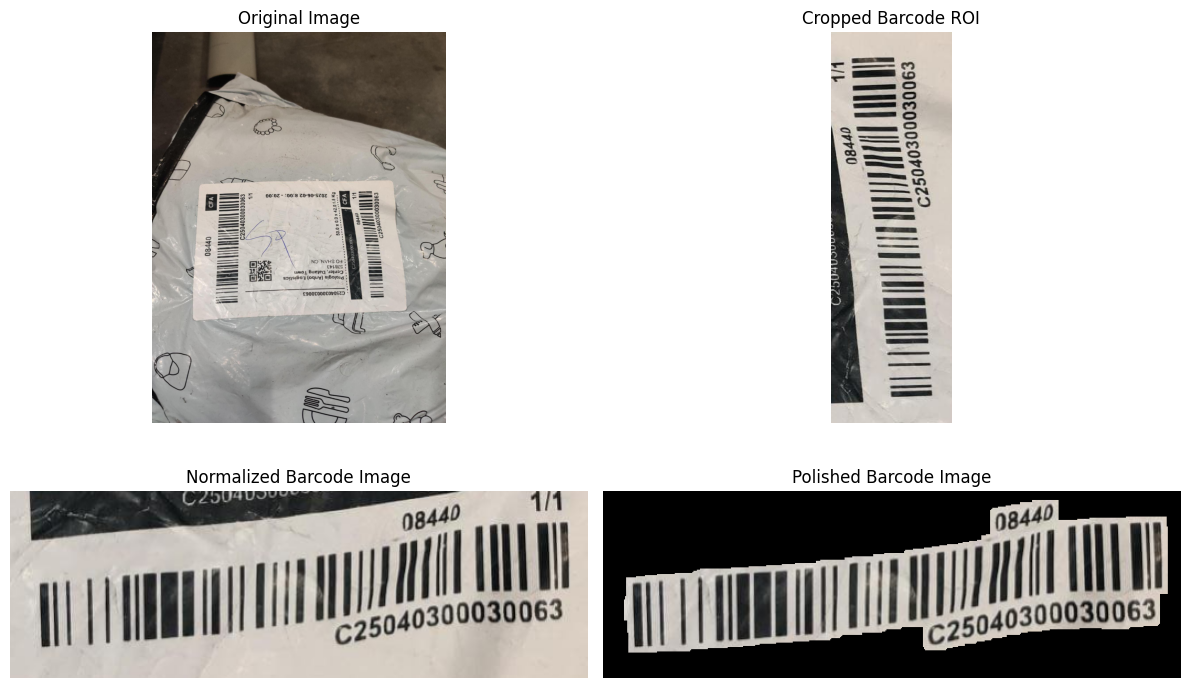

Barcode 2: barcode: 0.26


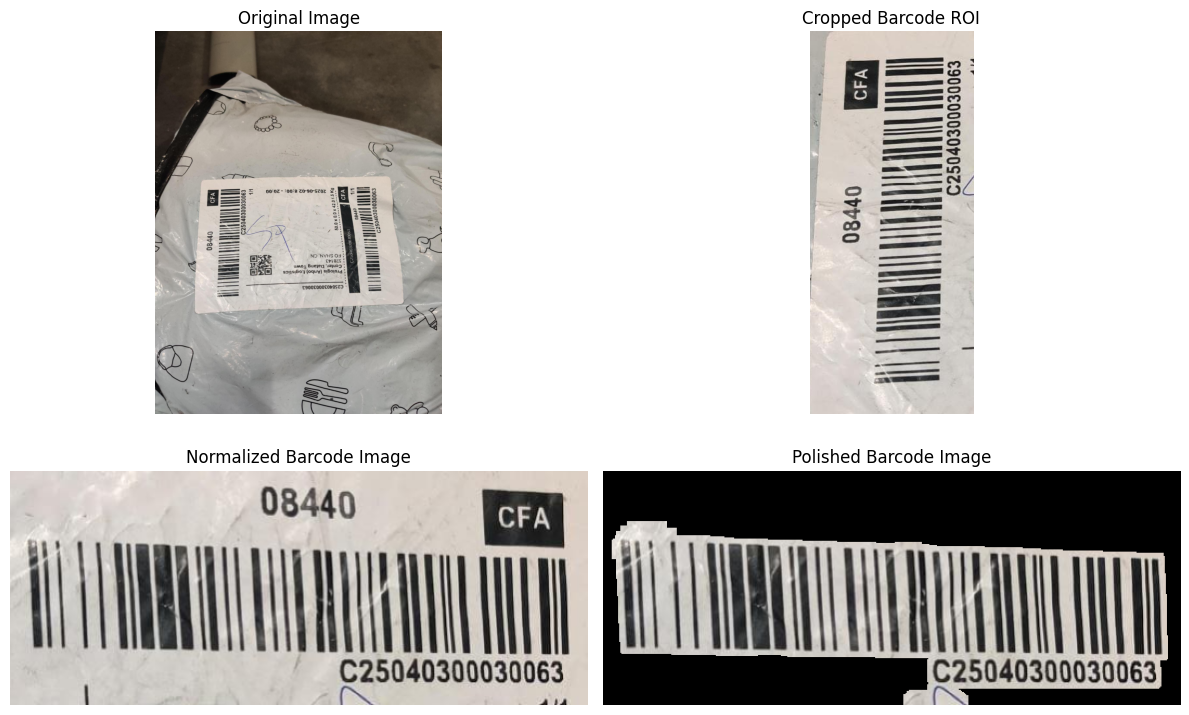


--- Detected Barcodes in Image 5 ---
Barcode 1: barcode: 0.80


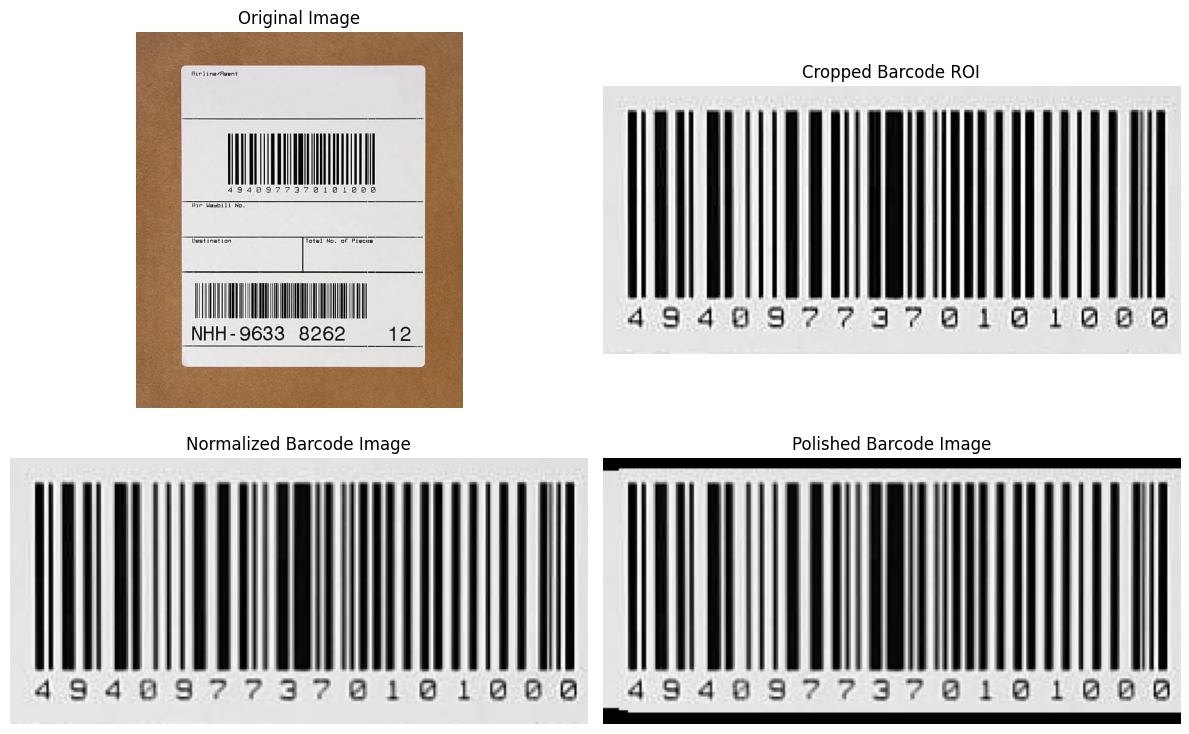

Barcode 2: barcode: 0.71


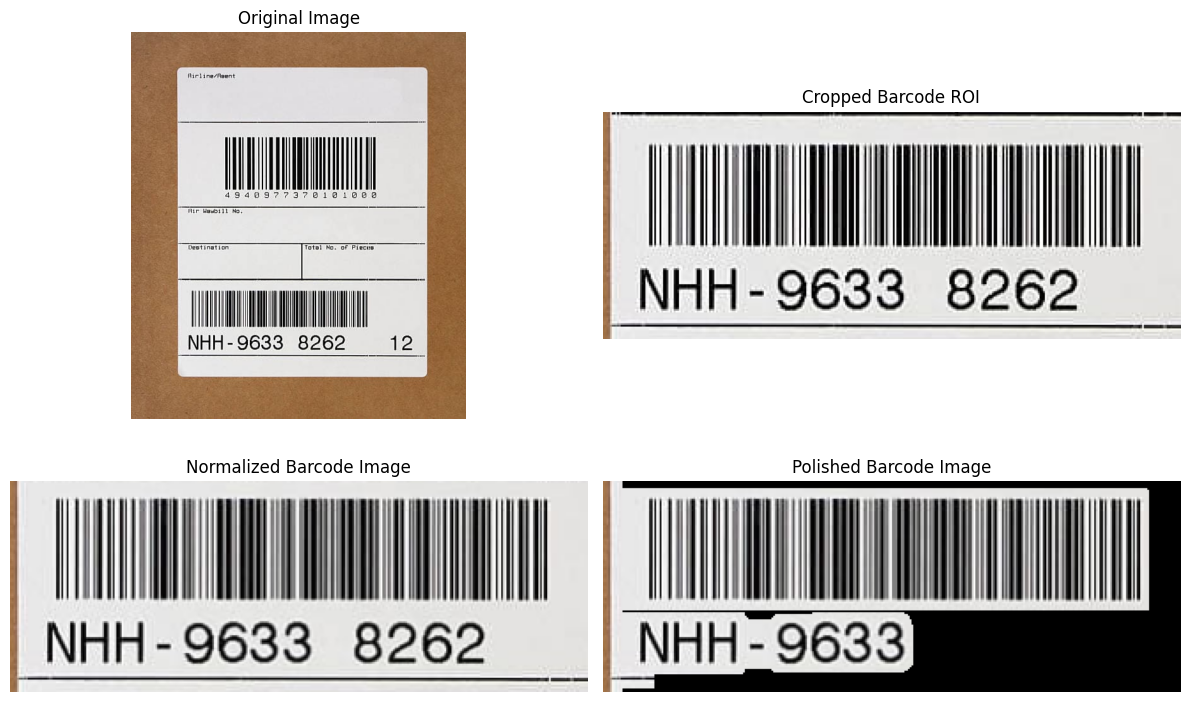


--- Detected Barcodes in Image 6 ---
Barcode 1: barcode: 0.60


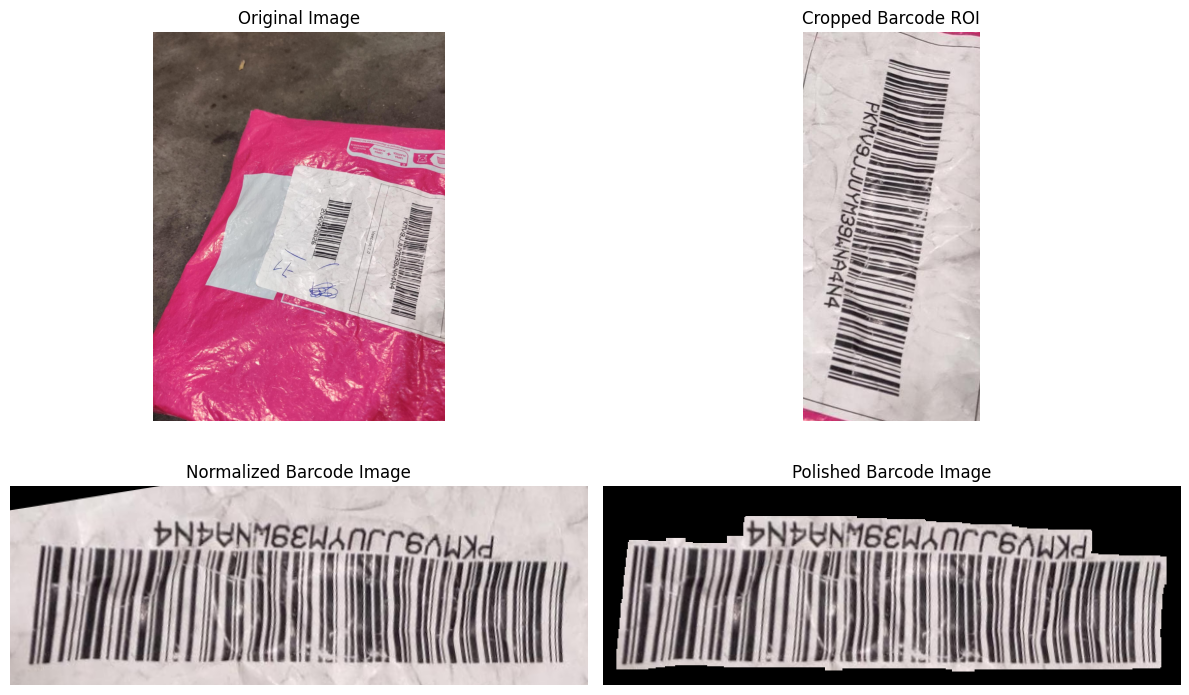

Barcode 2: barcode: 0.60


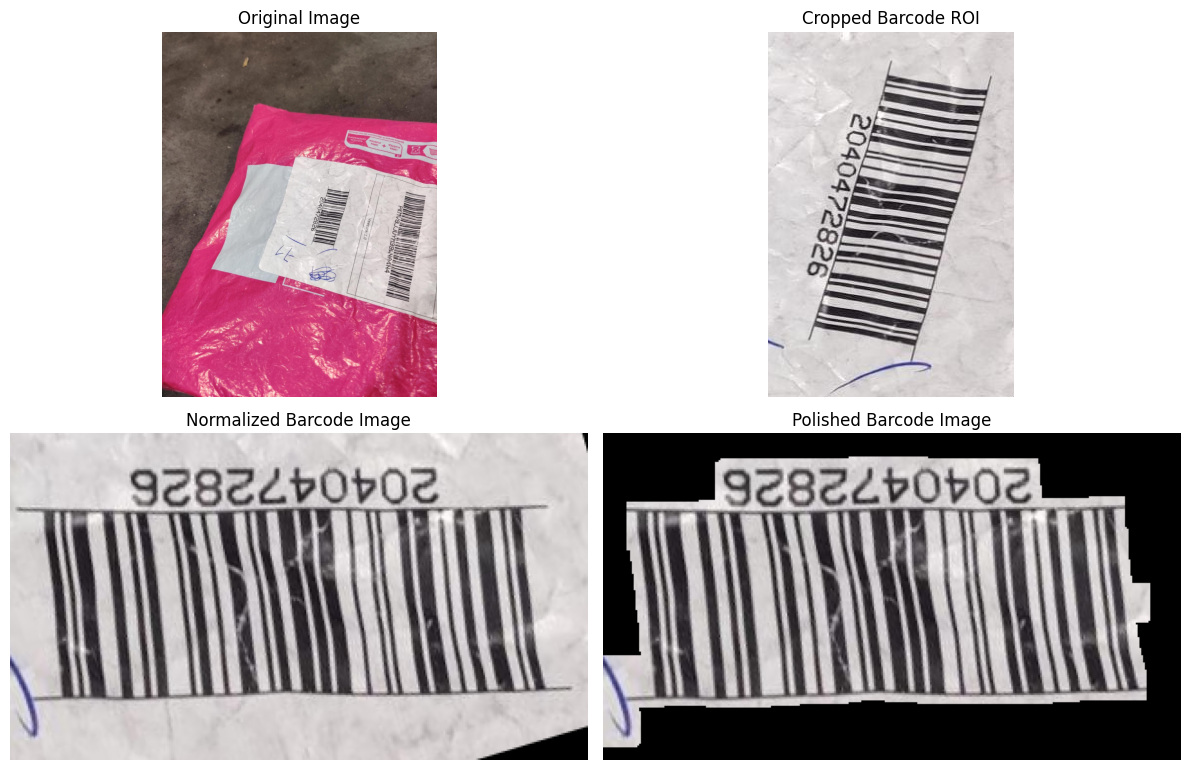

In [49]:
for i, image_barcodes in enumerate(detected_barcode_images):
    print(f"\n--- Detected Barcodes in Image {i+1} ---")

    for j, barcode in enumerate(image_barcodes):
        print(f"Barcode {j+1}: {barcode['label']}")

        original_image = barcode['original_image']
        cropped_barcode_roi = barcode['cropped_barcode_roi']
        normalized_barcode_image = barcode['normalized_barcode_image']
        polished_barcode_image = barcode['polished_barcode_image']

        plt.figure(figsize=(12, 8))

        plt.subplot(2, 2, 1)
        plt.title("Original Image")
        plt.imshow(cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB))
        plt.axis('off')

        plt.subplot(2, 2, 2)
        plt.title("Cropped Barcode ROI")
        plt.imshow(cv2.cvtColor(cropped_barcode_roi, cv2.COLOR_BGR2RGB))
        plt.axis('off')

        plt.subplot(2, 2, 3)
        plt.title("Normalized Barcode Image")
        plt.imshow(cv2.cvtColor(normalized_barcode_image, cv2.COLOR_BGR2RGB))
        plt.axis('off')

        plt.subplot(2, 2, 4)
        plt.title("Polished Barcode Image")
        if polished_barcode_image is not None:
            plt.imshow(cv2.cvtColor(polished_barcode_image, cv2.COLOR_BGR2RGB))
            plt.axis('off')
        else:
            print("Warning: Polished barcode image is None.")

        plt.tight_layout()
        plt.show()

#### Block 9: Deconding the Barcode
This block contains the decoding logic for the normalized barcode images.

In [50]:
_SKEW_ANGLE_THRESHOLD_DEGREES = 45.0
_HOUGH_LINE_THRESHOLD = 50
_HOUGH_LINE_MAX_GAP = 10

# for decode_barcode
_ADAPTIVE_THRESHOLD_BLOCK_SIZE = 55
_ADAPTIVE_THRESHOLD_C = 15
_MODULE_WIDTH_CHUNK_SIZE = 6
_MODULE_WIDTH_SUM_DIVISOR = 11.0
_MODULE_WIDTH_TOLERANCE = 0.2  # 20% tolerance around the median


def plot_barcode_decoding_results(
    normalized_image: np.ndarray,
    thresh: np.ndarray,
    scan_lines_y: list[float]
) -> None:
    """Plots the results of the barcode decoding process, including the original
    image, the binarized image with scanlines, and the scanline plot at the
    middle height of the image.

    Args:
        normalized_image (np.ndarray): The perspective-corrected and normalized
            barcode image.
        thresh (np.ndarray): The binarized image after adaptive thresholding.
        scan_lines_y (list[float]): List of Y-coordinates for the scanlines
            to be plotted.
    """
    h, w = thresh.shape
    scanline_y_half = h // 2
    scanline_at_h_half = thresh[scanline_y_half]

    # plotting with GridSpec for the desired layout
    fig = plt.figure(figsize=(15, 7)) # adjust overall figure size as needed
    gs = fig.add_gridspec(2, 2) # 2 rows, 2 columns grid

    # Top-left quarter: original Image
    ax1 = fig.add_subplot(gs[0, 0]) # Row 0, Column 0
    ax1.imshow(cv2.cvtColor(normalized_image, cv2.COLOR_BGR2RGB))
    ax1.set_title("1. Original Image")
    ax1.axis('off')

    # Bottom-left quarter: binarized Image with Scanlines
    ax2 = fig.add_subplot(gs[1, 0]) # Row 1, Column 0
    ax2.imshow(thresh, cmap='gray')
    for y in scan_lines_y:
        ax2.axhline(y=y, color='r', linestyle='--', alpha=0.5)
    ax2.set_title("2. Binarized Image with Scanlines")
    ax2.axis('off')

    # Right half: scanline plot
    ax3 = fig.add_subplot(gs[:, 1]) # All rows, Column 1 (spans both rows)
    ax3.plot(scanline_at_h_half)
    ax3.set_title(f"3. Scanline at Y={scanline_y_half}")
    ax3.set_xlabel("Pixel X-coordinate")
    ax3.set_ylabel("Pixel Value (0 or 255)")
    ax3.set_ylim([-10, 265])
    ax3.grid(True)

    plt.tight_layout()
    plt.show()


def _calculate_skew_angle(gray_image: np.ndarray) -> float | None:
    """Calculates the skew angle of the dominant lines in a grayscale image.

    Args:
        gray_image: A grayscale input image.

    Returns:
        The rotational correction angle in degrees, or None if no suitable
        lines are found.
    """
    _, thresh = cv2.threshold(
        gray_image, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    # use a relative minLineLength for robustness to image size
    min_line_length = int(gray_image.shape[0] * 0.4)
    lines = cv2.HoughLinesP(
        thresh, 1, np.pi / 180,
        threshold=_HOUGH_LINE_THRESHOLD,
        minLineLength=min_line_length,
        maxLineGap=_HOUGH_LINE_MAX_GAP
    )

    if lines is None:
        print("No lines detected by Hough Transform.")
        return None

    angles = []
    for line in lines:
        x1, y1, x2, y2 = line[0]
        # use np.arctan2 for a more robust angle calculation
        angle = np.degrees(np.arctan2(y2 - y1, x2 - x1))
        if abs(angle) > _SKEW_ANGLE_THRESHOLD_DEGREES:
            angles.append(angle)

    if not angles:
        print("No lines found exceeding the angle threshold.")
        return None

    median_angle = np.median(angles)
    # correction angle aims to make the median line vertical (90 degrees)
    return median_angle - 90.0


def fine_tune_rotation(image: np.ndarray) -> np.ndarray:
    """
    Detects the skew of an image and rotates it to make barcode lines vertical.

    Args:
        image: The input BGR image.

    Returns:
        The rotated image. If no rotation is needed or possible, returns the
        original image.
    """
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    rotation_angle = _calculate_skew_angle(gray)

    if rotation_angle is None:
        return image

    h, w = image.shape[:2]
    center = (w // 2, h // 2)

    rotation_matrix = cv2.getRotationMatrix2D(center, rotation_angle, 1.0)
    rotated_image = cv2.warpAffine(
        image, rotation_matrix, (w, h),
        flags=cv2.INTER_CUBIC,
        borderMode=cv2.BORDER_REPLICATE
    )
    return rotated_image


def _extract_run_lengths(scanline: np.ndarray) -> list[int] | None:
    """Extracts the lengths of consecutive runs of black/white pixels.

    Args:
        scanline: A 1D numpy array representing a binarized image scanline.

    Returns:
        A list of run lengths, or None if the scanline is invalid.
    """
    # a valid barcode shouldn't start with a black bar on the edge
    if scanline[0] == 0:
        return None

    # find indices where the color changes
    diffs = np.diff(scanline)
    change_indices = np.where(diffs != 0)[0] + 1

    # calculate run lengths from the change indices
    run_lengths = np.diff(
        np.concatenate(([0], change_indices, [len(scanline)]))
    )
    # exclude the first and last runs which are quiet zones
    return run_lengths[1:-1].tolist()


def _calculate_module_width(run_lengths: list[int]) -> float | None:
    """Calculates the fundamental module width from bar/space run lengths.

    This uses a robust method of averaging local estimates to find the width
    of the narrowest bar/space in the barcode.

    Args:
        run_lengths: A list of bar and space widths.

    Returns:
        The calculated module width as a float, or None on failure.
    """
    if len(run_lengths) < _MODULE_WIDTH_CHUNK_SIZE:
        print("Not enough run lengths to form a chunk.")
        return None

    tot = len(run_lengths) - _MODULE_WIDTH_CHUNK_SIZE + 1
    # estimate module width from chunks of 6 bars/spaces (1 symbol)
    local_module_widths = [
        sum(run_lengths[i:i+_MODULE_WIDTH_CHUNK_SIZE]) / _MODULE_WIDTH_SUM_DIVISOR
        for i in range(0, tot, _MODULE_WIDTH_CHUNK_SIZE)
    ]

    if not local_module_widths:
        print("Could not calculate any local module widths.")
        return None

    # filter out outliers before taking the mean
    median_width = np.median(local_module_widths)
    tolerance = median_width * _MODULE_WIDTH_TOLERANCE
    valid_widths = [
        w for w in local_module_widths
        if (median_width - tolerance) < w < (median_width + tolerance)
    ]

    if not valid_widths:
        print("No valid module widths found after filtering.")
        return None

    return np.mean(valid_widths)


def _decode_patterns(normalized_widths: list[int]) -> list[int]:
    """Decodes normalized bar widths into Code 128 character values.

    Args:
        normalized_widths: A list of integer widths normalized by module width.

    Returns:
        A list of decoded integer values.

    Raises:
        ValueError: If the start/stop patterns are not found or a character
                       pattern is invalid.
    """
    # attempt to read forward
    if tuple(normalized_widths[:6]) != START_B_PATTERN:
        # if that fails, try reading in reverse
        print("Forward read failed, attempting reverse.")
        normalized_widths.reverse()
        if tuple(normalized_widths[:6]) != START_B_PATTERN:
            raise ValueError(
                f"Start pattern not found. Got: {normalized_widths[:6]}"
            )

    decoded_values = [104]  # Start B
    cursor = 6

    while True:
        # check for stop pattern before decoding another character
        if cursor + 7 <= len(normalized_widths) and \
           tuple(normalized_widths[cursor : cursor + 7]) == STOP_PATTERN:
            break

        if cursor + 6 > len(normalized_widths):
            raise ValueError("Incomplete final character pattern.")

        char_pattern = tuple(normalized_widths[cursor : cursor + 6])
        if sum(char_pattern) != 11:
            raise ValueError(
                f"Invalid character pattern sum for {char_pattern}"
            )

        if char_pattern not in CODE128_MAP:
            raise ValueError(f"Unknown character pattern: {char_pattern}")

        decoded_values.append(CODE128_MAP[char_pattern][0])
        cursor += 6

    return decoded_values


def _validate_and_construct_string(decoded_values: list[int]) -> str:
    """Validates the checksum and constructs the final string.

    Args:
        decoded_values: The list of decoded values, including start and checksum.

    Returns:
        The final decoded string.

    Raises:
        ValueError: If the checksum is invalid.
    """
    if len(decoded_values) < 2:
        raise ValueError("Not enough data for checksum validation.")

    checksum_value = decoded_values.pop()
    # first value (Start B) has a weight of 1
    weighted_sum = sum(
        value * (i + 1) for i, value in enumerate(decoded_values)
    )
    calculated_checksum = weighted_sum % 103

    if calculated_checksum != checksum_value:
        raise ValueError(
            f"Checksum mismatch! Expected: {calculated_checksum}, "
            f"Got: {checksum_value}"
        )

    # exclude Start B value from the final string
    data_values = decoded_values[1:]
    return "".join([VALUE_TO_CHAR_B.get(v, '?') for v in data_values])


def decode_barcode(normalized_image: np.ndarray) -> str | None:
    """
    Decodes a Code 128 barcode from a pre-normalized and oriented image.

    Args:
        normalized_image (np.ndarray): An image containing a barcode,
            finely rotated.

    Returns:
        The decoded barcode string, or None if decoding fails.
    """
    if normalized_image is None: return None

    finely_rotated_image = fine_tune_rotation(normalized_image)

    gray = cv2.cvtColor(finely_rotated_image, cv2.COLOR_BGR2GRAY)
    thresh = cv2.adaptiveThreshold(
        gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY,
        _ADAPTIVE_THRESHOLD_BLOCK_SIZE, _ADAPTIVE_THRESHOLD_C
    )

    # for robustness, one could sample multiple scanlines and average results
    # or take the first successful decode. Here, we use the center scanline.
    h, _ = thresh.shape
    scanline = thresh[h // 2]

    scan_lines_y = [int(h * p) for p in np.arange(0.40, 0.65, 0.05)]
    plot_barcode_decoding_results(normalized_image, thresh, scan_lines_y)

    run_lengths = _extract_run_lengths(scanline)
    if not run_lengths:
        print("Failed to extract valid run lengths.")
        return None

    module_width = _calculate_module_width(run_lengths)
    if not module_width:
        print("Failed to calculate module width.")
        return None
    print(f"Calculated Module Width: {module_width:.2f}")

    normalized_widths = [round(w / module_width) for w in run_lengths]
    print(f"Normalized Widths: {normalized_widths}")

    try:
        patterns = _decode_patterns(normalized_widths)
        result_string = _validate_and_construct_string(patterns)
        return result_string
    except Exception as e:
        print(f"DECODING ERROR: {e}")
        return None

#### Block 10: Display Results
This cell displays the original cropped barcode image and its normalized counterpart. It also attempts to decode the normalized image and prints the result, indicating success or failure.

No lines found exceeding the angle threshold.


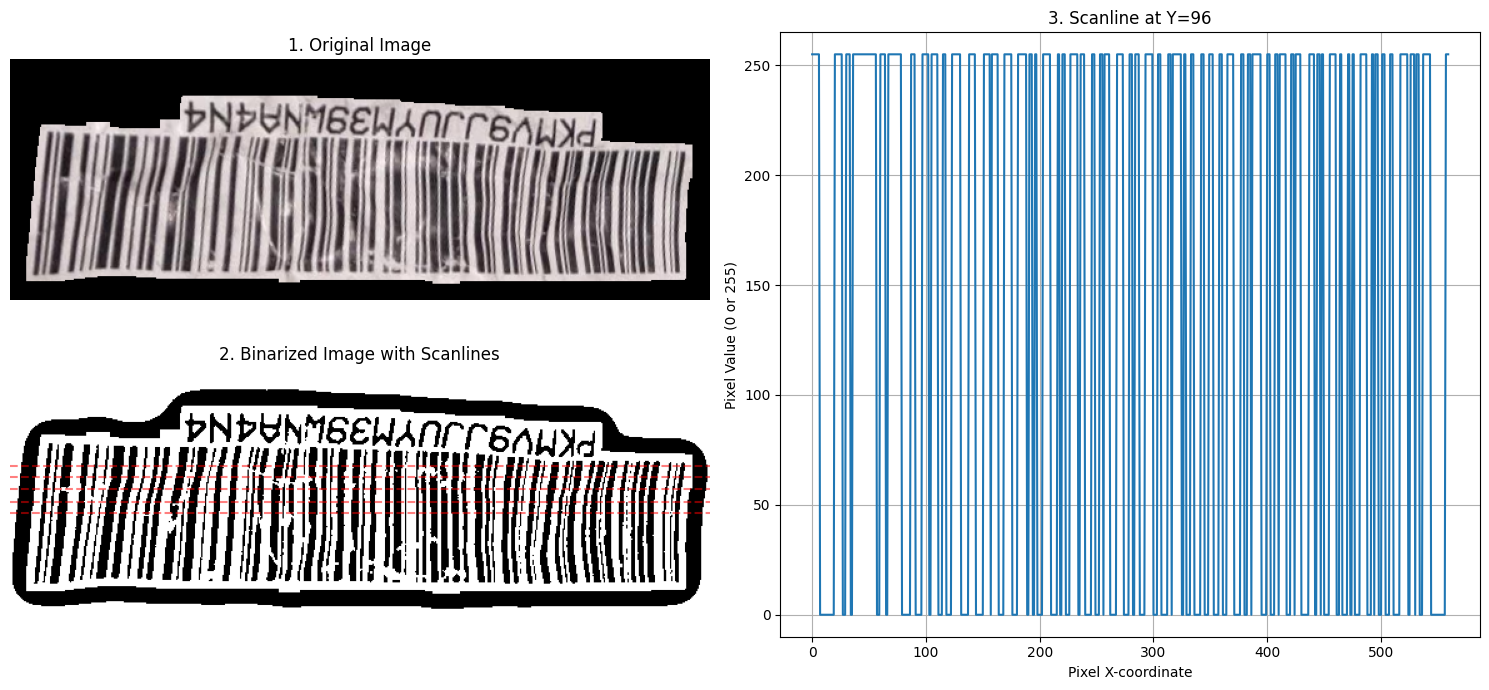

Calculated Module Width: 2.16
Normalized Widths: [6, 3, 1, 2, 1, 10, 1, 2, 1, 6, 4, 2, 3, 3, 1, 3, 2, 1, 2, 4, 3, 3, 3, 3, 0, 3, 2, 3, 2, 4, 1, 1, 1, 1, 2, 3, 3, 1, 1, 1, 2, 3, 1, 2, 3, 1, 2, 1, 0, 2, 3, 3, 2, 1, 1, 2, 2, 3, 2, 1, 3, 1, 0, 4, 1, 1, 2, 1, 3, 1, 2, 2, 2, 1, 2, 3, 3, 1, 1, 1, 0, 4, 2, 1, 2, 1, 0, 3, 2, 1, 0, 2, 3, 2, 1, 1, 0, 1, 2, 3, 1, 1, 2, 1, 1, 1, 2, 3, 2, 1, 0, 1, 1, 1, 2, 1, 3, 3, 1, 2, 0, 1, 1, 3, 6]
Forward read failed, attempting reverse.
DECODING ERROR: Start pattern not found. Got: [6, 3, 1, 1, 0, 2]
FAILED: Could not decode normalized image.
No lines found exceeding the angle threshold.


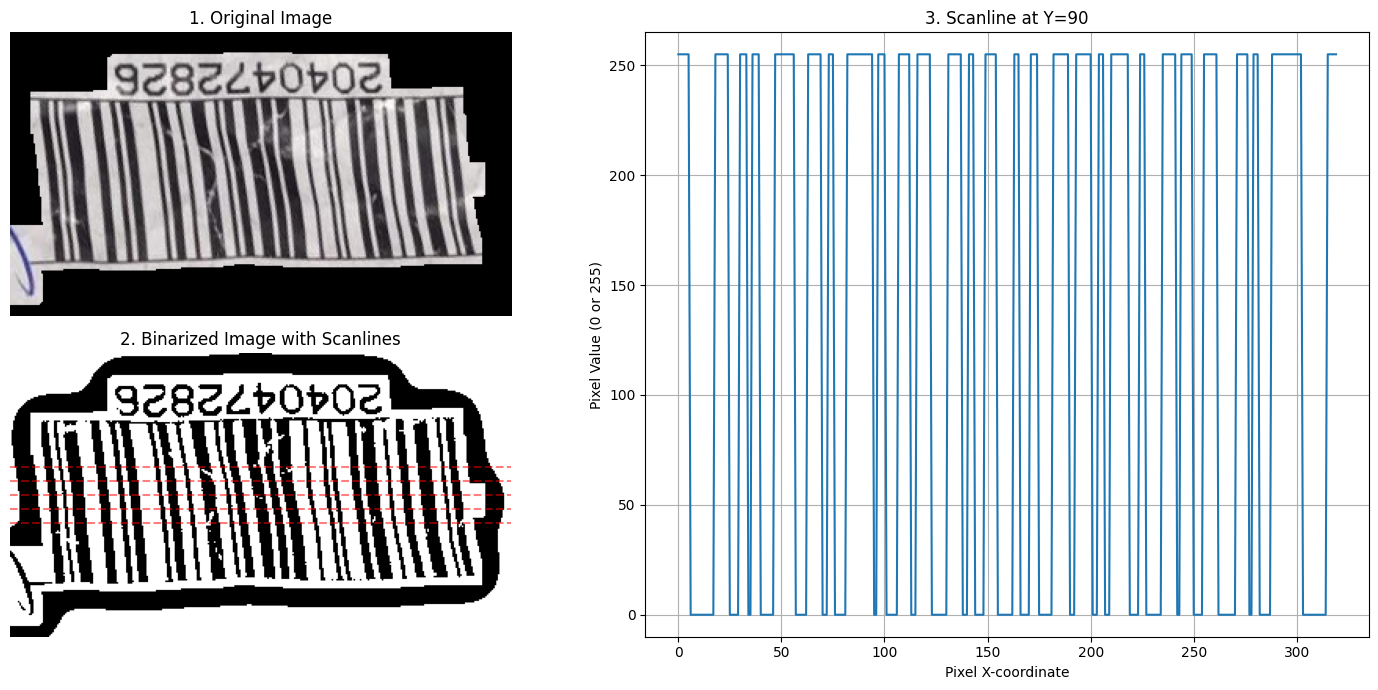

Calculated Module Width: 3.08
Normalized Widths: [4, 2, 2, 1, 1, 1, 2, 3, 2, 2, 1, 1, 2, 4, 1, 1, 2, 2, 1, 2, 3, 2, 1, 1, 2, 2, 3, 1, 2, 1, 2, 3, 1, 3, 1, 1, 1, 3, 2, 1, 3, 2, 1, 2, 2, 2, 3, 2, 1, 1, 2, 5, 4]
Forward read failed, attempting reverse.
DECODING ERROR: Start pattern not found. Got: [4, 5, 2, 1, 1, 2]
FAILED: Could not decode normalized image.


In [40]:
for all_barcodes in detected_barcode_images:
    if not all_barcodes:
        continue

    for barcode in all_barcodes:
        original_image = barcode['original_image']
        polished_barcode_image = barcode['polished_barcode_image']

        if normalized_img is None:
            print("FAILED: Normalized image is None.")
            continue

        decoded_code = decode_barcode(polished_barcode_image)

        if decoded_code:
            print(f"SUCCESS: Decoded {decoded_code}")
        else:
            print("FAILED: Could not decode normalized image.")

        # TODO: Save the code to a csv file